# 502 GPU

View more, visit my tutorial page: https://morvanzhou.github.io/tutorials/
My Youtube Channel: https://www.youtube.com/user/MorvanZhou

Dependencies:
* torch: 1.0.0
* torchvision

https://ptorch.com/docs/4/pytorch-video-GPU

使用`.cuda`函数可以将张量移动到GPU上，从而享受GPU带来的加速运算。  

所有在CPU上的张量，除了字符张量，都支持在numpy之间转换。

In [2]:
import torch
import torch.nn as nn
from torch.autograd import Variable
import torch.utils.data as Data
import torchvision

torch.manual_seed(1)

import matplotlib.pyplot as plt
%matplotlib inline

In [14]:
# cuda是否可用
print(torch.cuda.is_available())

# 返回gpu数量
print(torch.cuda.device_count())

# 返回gpu名字，设备索引默认从0开始
print(torch.cuda.get_device_name(0))

# 返回当前设备索引
print(torch.cuda.current_device())

True
1
GeForce RTX 2080 Ti
0


In [3]:
# run this cell only if CUDA is available
if torch.cuda.is_available():
    x = x.cuda()
    y = y.cuda()
    print(x + y)

In [8]:
x = torch.rand(5, 3)
y = torch.rand(5, 3)

# 在不支持CUDA的机器下，下一步还是在CPU上运行
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
# Tensors can be moved onto any device using the .to method.
x = x.to(device)
y = y.to(device)
print(x+y)

tensor([[1.2126, 0.8518, 0.9011],
        [1.6718, 0.6849, 1.1137],
        [0.5952, 1.1706, 0.8538],
        [0.7786, 1.1626, 1.3227],
        [1.4544, 0.3164, 1.2735]])


In [9]:
# run this cell only if CUDA is available
# use ``torch.device`` objects to move tensors in and out of GPU
if torch.cuda.is_available():
    device = torch.device("cuda")          # a CUDA device object
    y = torch.ones_like(x, device=device)  # directly create a tensor on GPU
    x = x.to(device)                       # or just use strings ``.to("cuda")``
    z = x + y
    print(z)
    print(z.to("cpu", torch.double))       # ``.to`` can also change dtype together!

此外，还可以使用`tensor.cuda()` 的方式将tensor拷贝到gpu上，但是这种方式不太推荐。

此处可能发现GPU运算的速度并未提升太多，这是因为x和y太小且运算也较为简单，而且将数据从内存转移到显存还需要花费额外的开销。GPU的优势需在大规模数据和复杂运算下才能体现出来。

### 识别手写数字

In [2]:
EPOCH = 1
BATCH_SIZE = 50
LR = 0.001
DOWNLOAD_MNIST = False

In [3]:
train_data = torchvision.datasets.MNIST(
    root='./mnist/', 
    train=True, 
    transform=torchvision.transforms.ToTensor(), 
    download=DOWNLOAD_MNIST,)

train_loader = Data.DataLoader(
    dataset=train_data, 
    batch_size=BATCH_SIZE, 
    shuffle=True)

test_data = torchvision.datasets.MNIST(
    root='./mnist/', train=False)

# !!!!!!!! Change in here !!!!!!!!! #
test_x = Variable(torch.unsqueeze(test_data.test_data, dim=1)).type(torch.FloatTensor)[:2000].cuda()/255. # Tensor on GPU
test_y = test_data.test_labels[:2000].cuda()

In [4]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.conv1 = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=16, kernel_size=5, stride=1, padding=2,),                      
            nn.ReLU(), 
            nn.MaxPool2d(kernel_size=2),)
        self.conv2 = nn.Sequential(
            nn.Conv2d(16, 32, 5, 1, 2), 
            nn.ReLU(), 
            nn.MaxPool2d(2),)
        self.out = nn.Linear(32 * 7 * 7, 10)

    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = x.view(x.size(0), -1)
        output = self.out(x)
        return output

In [5]:
cnn = CNN()

# !!!!!!!! Change in here !!!!!!!!! #
cnn.cuda()      # Moves all model parameters and buffers to the GPU.

CNN(
  (conv1): Sequential(
    (0): Conv2d(1, 16, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv2): Sequential(
    (0): Conv2d(16, 32, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (out): Linear(in_features=1568, out_features=10, bias=True)
)

In [6]:
optimizer = torch.optim.Adam(cnn.parameters(), lr=LR)
loss_func = nn.CrossEntropyLoss()

losses_his = []

### Training

In [9]:
for epoch in range(EPOCH):
    for step, (x, y) in enumerate(train_loader):

        # !!!!!!!! Change in here !!!!!!!!! #
        b_x = Variable(x).cuda()    # Tensor on GPU
        b_y = Variable(y).cuda()    # Tensor on GPU

        output = cnn(b_x)
        loss = loss_func(output, b_y)
        losses_his.append(loss.data.item())
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if step % 50 == 0:
            test_output = cnn(test_x)

            # !!!!!!!! Change in here !!!!!!!!! #
            pred_y = torch.max(test_output, 1)[1].cuda().data.squeeze()  # move the computation in GPU

            accuracy = torch.sum(pred_y == test_y).type(torch.FloatTensor) / test_y.size(0)
            print('Epoch: ', epoch, '| train loss: %.4f' % loss.data.item(), '| test accuracy: %.2f' % accuracy)

Epoch:  0 | train loss: 2.2759 | test accuracy: 0.15
Epoch:  0 | train loss: 0.5997 | test accuracy: 0.83
Epoch:  0 | train loss: 0.2845 | test accuracy: 0.89
Epoch:  0 | train loss: 0.1593 | test accuracy: 0.90
Epoch:  0 | train loss: 0.1017 | test accuracy: 0.93
Epoch:  0 | train loss: 0.1076 | test accuracy: 0.94
Epoch:  0 | train loss: 0.2076 | test accuracy: 0.95
Epoch:  0 | train loss: 0.1616 | test accuracy: 0.95
Epoch:  0 | train loss: 0.1724 | test accuracy: 0.96
Epoch:  0 | train loss: 0.2212 | test accuracy: 0.96
Epoch:  0 | train loss: 0.0955 | test accuracy: 0.97
Epoch:  0 | train loss: 0.0778 | test accuracy: 0.97
Epoch:  0 | train loss: 0.0213 | test accuracy: 0.96
Epoch:  0 | train loss: 0.1520 | test accuracy: 0.96
Epoch:  0 | train loss: 0.0652 | test accuracy: 0.97
Epoch:  0 | train loss: 0.0848 | test accuracy: 0.97
Epoch:  0 | train loss: 0.1026 | test accuracy: 0.97
Epoch:  0 | train loss: 0.0436 | test accuracy: 0.98
Epoch:  0 | train loss: 0.0602 | test accuracy

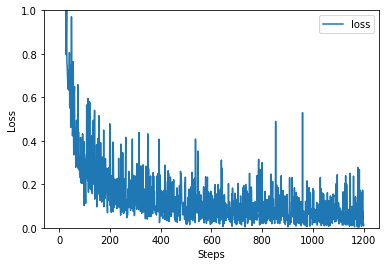

In [10]:
plt.plot(losses_his, label='loss')
plt.legend(loc='best')
plt.xlabel('Steps')
plt.ylabel('Loss')
plt.ylim((0, 1))
plt.show()

### Test

In [11]:
# !!!!!!!! Change in here !!!!!!!!! #
test_output = cnn(test_x[:10])
pred_y = torch.max(test_output, 1)[1].cuda().data.squeeze() # move the computation in GPU

# 使数据转换为cpu格式，才能使用numpy、matplotlib等库进行处理
# pred_y = pred_y.cpu()

print(pred_y, 'prediction number')
print(test_y[:10], 'real number')

tensor([7, 2, 1, 0, 4, 1, 4, 9, 5, 9], device='cuda:0') prediction number
tensor([7, 2, 1, 0, 4, 1, 4, 9, 5, 9], device='cuda:0') real number
